# Imports

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

In [ ]:
# Wavelength of light (green laser, 532nm)
wavelength = 532e-9  # meters

# Sensor/grid size
N = 512             # grid points
pixel_size = 5e-6   # 5 micrometers (typical image sensor pixel)
L = N * pixel_size  # physical size of the sensor

# Propagation distance
z = 0.5            # 5cm from object to sensor

# Spatial coordinates
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)

# Simple aperture

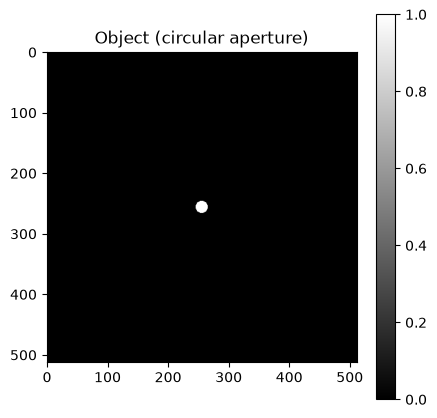

In [21]:
# Circular aperture as our object
radius = 50e-6  # 50 micrometers
U0 = (np.sqrt(X**2 + Y**2) < radius).astype(complex)

plt.figure(figsize=(5,5))
plt.imshow(np.abs(U0), cmap='gray')
plt.title('Object (circular aperture)')
plt.colorbar()
plt.show()

# Angular Spectrum Method Propagation

In [22]:
def propagate_asm(U0, wavelength, pixel_size, z):
    N = U0.shape[0]
    
    # Frequency coordinates
    fx = np.fft.fftfreq(N, d=pixel_size)
    fy = np.fft.fftfreq(N, d=pixel_size)
    FX, FY = np.meshgrid(fx, fy)
    
    # Transfer function
    k = 1 / wavelength
    kernel = k**2 - FX**2 - FY**2
    
    # Only propagate valid frequencies (avoid evanescent waves)
    valid = kernel >= 0
    H = np.zeros((N, N), dtype=complex)
    H[valid] = np.exp(1j * 2 * np.pi * z * np.sqrt(kernel[valid]))
    
    # Propagate: FFT -> apply H -> IFFT
    U_fft = np.fft.fft2(U0)
    U_propagated = np.fft.ifft2(U_fft * H)
    
    return U_propagated

# Visualization

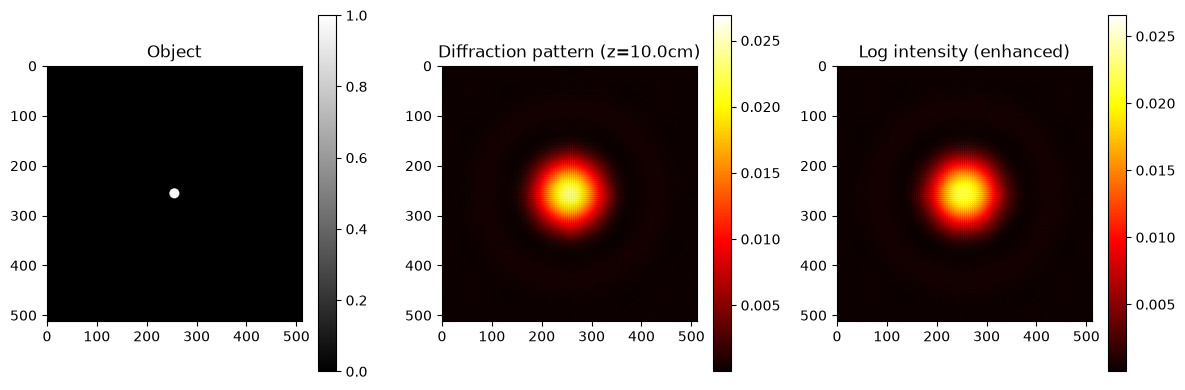

In [23]:
U_sensor = propagate_asm(U0, wavelength, pixel_size, z)

# Intensity pattern at sensor
I = np.abs(U_sensor)**2

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(U0), cmap='gray')
plt.title('Object')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(I, cmap='hot')
plt.title(f'Diffraction pattern (z={z*100}cm)')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(np.log1p(I), cmap='hot')
plt.title('Log intensity (enhanced)')
plt.colorbar()

plt.tight_layout()
plt.show()